## Business-Oriented EDA (Analisis Diagnostik Operasional)
Tahap ini berfokus pada analisis pola biaya, subsidi, dan risiko pembatalan untuk mengidentifikasi potensi inefisiensi operasional.

Analisis dilakukan berbasis segmentasi wilayah dan metode pembayaran dengan tujuan menjawab pertanyaan utama berikut:
- Bagaimana struktur biaya pengiriman aktual?
- Seberapa efektif kebijakan subsidi?
- Apakah biaya logistik berkaitan dengan tingkat pembatalan?

Bagian ini terdiri dari empat komponen utama:
- Struktur Biaya Pengiriman
- Evaluasi Subsidi
- Risiko Pembatalan
- Segmentasi Inefisiensi
- Temuan dari analisis ini akan menjadi dasar rekomendasi strategis pada bagian akhir laporan.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

base = Path("/Users/a/Documents/operasional_ecommers_indo/data/process")
print("exists folder:", base.exists())
print("files:", [p.name for p in base.glob("*.csv")])

df = pd.read_csv(base / "dataset_preprocessed_full.csv")
df_paid = pd.read_csv(base / "dataset_preprocessed_paid_shipping.csv")

print("Full dataset:", df.shape)
print("Paid shipping:", df_paid.shape)



exists folder: True
files: ['dataset_preprocessed_full.csv', 'dataset_preprocessed_paid_shipping.csv']
Full dataset: (20848, 22)
Paid shipping: (6296, 23)


### 1. Struktur Biaya Pengiriman
Bagian ini bertujuan untuk memahami bagaimana biaya logistik terdistribusi pada transaksi yang benar-benar membayar ongkir (df_paid).

Fokus analisis meliputi:
- Distribusi ongkir aktual
- Distribusi ongkir per kilogram
- Hubungan antara berat dan ongkir
- Perbandingan biaya antar provinsi

Analisis ini penting untuk mengidentifikasi apakah terdapat variasi biaya yang signifikan serta potensi inefisiensi dalam sistem distribusi.

#### a. Distribusi Ongkir Aktual

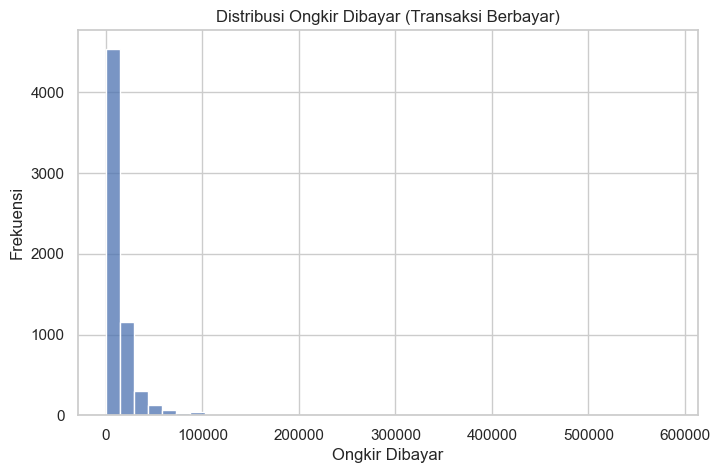

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df_paid["ongkir_dibayar"], bins=40)
plt.title("Distribusi Ongkir Dibayar (Transaksi Berbayar)")
plt.xlabel("Ongkir Dibayar")
plt.ylabel("Frekuensi")
plt.show()


Distribusi ini menunjukkan variasi biaya logistik yang benar-benar dibayarkan pelanggan.

Beberapa poin yang perlu diperhatikan:
- Apakah distribusi condong ke kanan (right-skewed)?
- Apakah terdapat nilai ekstrem?
- Di rentang berapa mayoritas ongkir berada?

Jika mayoritas ongkir terkonsentrasi pada rentang tertentu, maka struktur biaya relatif stabil.
Sebaliknya, variasi yang sangat lebar dapat mengindikasikan heterogenitas biaya distribusi antar wilayah atau perbedaan struktur tarif.

#### b. Distribusi Ongkir per Kilogram (Clipped)

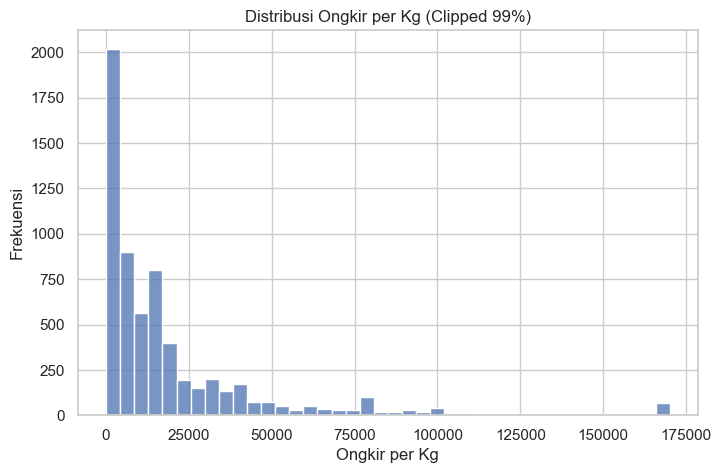

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df_paid["ongkir_per_kg_clipped"], bins=40)
plt.title("Distribusi Ongkir per Kg (Clipped 99%)")
plt.xlabel("Ongkir per Kg")
plt.ylabel("Frekuensi")
plt.show()



In [6]:

df_paid["ongkir_per_kg_clipped"].describe()

count      6296.000000
mean      20114.545645
std       28917.210029
min           0.227273
25%        3137.254902
50%       10000.000000
75%       22500.000000
max      170093.750000
Name: ongkir_per_kg_clipped, dtype: float64

Ongkir per kilogram memberikan gambaran efisiensi biaya relatif terhadap berat barang.
Beberapa interpretasi yang dapat dilakukan:
- Median mencerminkan biaya tipikal per kg
- Selisih antara median dan kuartil atas (75%) menunjukkan variasi biaya
- Jika distribusi sangat lebar, kemungkinan terdapat ketidakefisienan antar wilayah
- Nilai ekstrem telah dibatasi untuk menjaga representativitas visual tanpa menghapus data asl

#### c. Hubungan Berat dan Ongkir

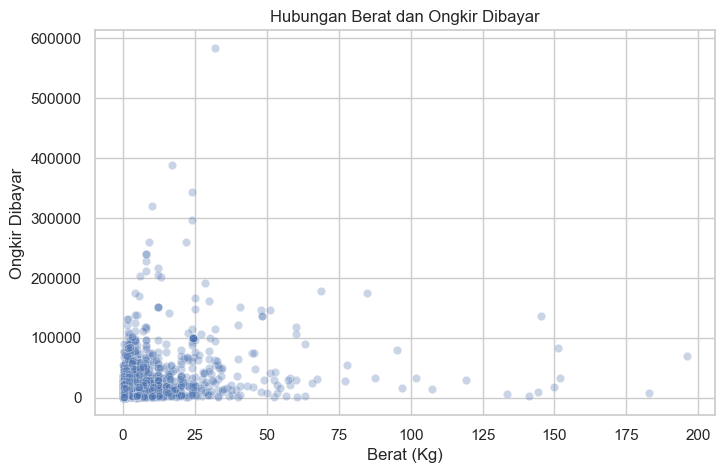

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df_paid["total_berat_kg"],
    y=df_paid["ongkir_dibayar"],
    alpha=0.3
)
plt.title("Hubungan Berat dan Ongkir Dibayar")
plt.xlabel("Berat (Kg)")
plt.ylabel("Ongkir Dibayar")
plt.show()


Secara logis, ongkir seharusnya meningkat seiring bertambahnya berat barang.
Jika pola linear terlihat jelas, maka struktur tarif relatif konsisten.

Namun jika terdapat penyimpangan besar, kemungkinan terdapat:
- Tarif minimum yang dominan
- Ketidaksesuaian estimasi ongkir
- Perbedaan struktur tarif antar wilayah
- Pola berlapis atau bertingkat juga dapat mengindikasikan sistem tarif berbasis pembulatan berat.

#### d. Perbandingan Ongkir per Kg antar Provinsi (Top 10)

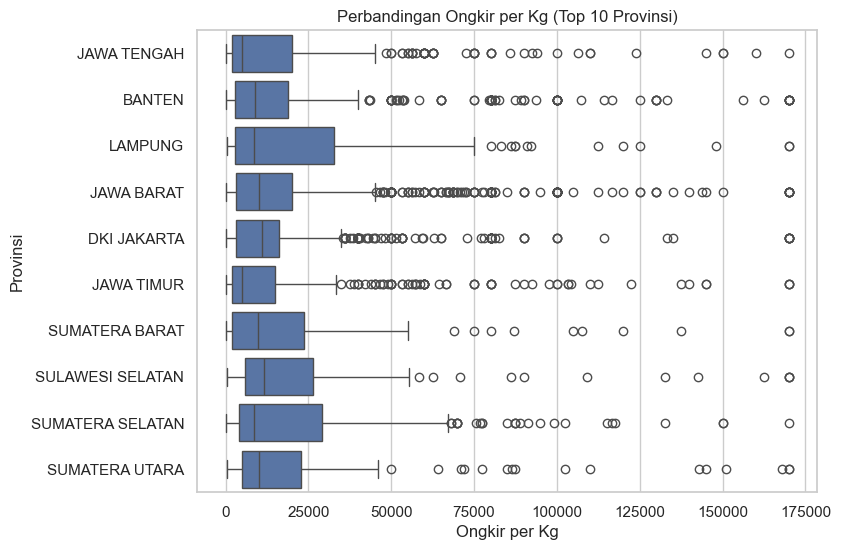

In [8]:
top_prov = df_paid["provinsi"].value_counts().head(10).index

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_paid[df_paid["provinsi"].isin(top_prov)],
    x="ongkir_per_kg_clipped",
    y="provinsi"
)
plt.title("Perbandingan Ongkir per Kg (Top 10 Provinsi)")
plt.xlabel("Ongkir per Kg")
plt.ylabel("Provinsi")
plt.show()


Perbandingan antar provinsi membantu mengidentifikasi:
- Wilayah dengan biaya logistik relatif tinggi
- Variasi distribusi biaya di tiap provinsi
- Potensi ketidakefisienan regional
- Provinsi dengan median ongkir per kg tinggi dapat menjadi kandidat evaluasi kebijakan distribusi atau subsidi.